# 📊 Superstore Sales Dashboard
**Complete Business Intelligence Analysis using Python, Pandas, Seaborn & Plotly Express**

---
**Dataset:** [Superstore Sales Dataset – Kaggle](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final)

**Author:** Patrick | VIIT Pune – AI/ML

**Analyses Included:**
1. Monthly Revenue Trend
2. Sales by Category & Sub-Category
3. Regional Sales Performance
4. Top 10 Products by Profit
5. Discount vs Profit Correlation
6. Customer Segment Analysis
7. Year-over-Year Growth Comparison
8. Key Business Recommendations

> **How to get the dataset:** Download `Sample - Superstore.csv` from the Kaggle link above and upload it to your Colab session (or place it in your working directory). Rename it to `Superstore.csv`.

In [1]:
# Install any missing libraries (Colab usually has these pre-installed)
!pip install plotly --quiet

In [2]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization Libraries ──────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Display Settings ─────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [3]:
# ── Load CSV ─────────────────────────────────────────────────────────────────
# Try UTF-8 first; fall back to latin-1 which handles special characters
try:
    df = pd.read_csv('Superstore.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('Superstore.csv', encoding='latin-1')

print(f'✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

✅ Dataset loaded: 9,994 rows × 21 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87


In [4]:
# ── 2.1  Inspect raw data ────────────────────────────────────────────────────
print('=== SHAPE ===');        print(df.shape)
print('\n=== DTYPES ===');     print(df.dtypes)
print('\n=== NULL COUNTS ==='); print(df.isnull().sum())

=== SHAPE ===
(9994, 21)

=== DTYPES ===
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

=== NULL COUNTS ===
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0


In [5]:
# ── 2.2  Fix column names (strip spaces & lower-case) ────────────────────────
df.columns = df.columns.str.strip().str.replace(' ', '_')

# ── 2.3  Parse date columns ──────────────────────────────────────────────────
for col in ['Order_Date', 'Ship_Date']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], infer_datetime_format=True)

# ── 2.4  Remove duplicate rows ───────────────────────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Duplicates removed: {before - len(df)}')

# ── 2.5  Handle nulls ────────────────────────────────────────────────────────
# Numeric nulls → 0 ; Categorical nulls → 'Unknown'
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns
df[num_cols] = df[num_cols].fillna(0)
df[cat_cols] = df[cat_cols].fillna('Unknown')

# ── 2.6  Derive helper columns ───────────────────────────────────────────────
df['Year']         = df['Order_Date'].dt.year
df['Month']        = df['Order_Date'].dt.month
df['Month_Name']   = df['Order_Date'].dt.strftime('%b')
df['YearMonth']    = df['Order_Date'].dt.to_period('M').astype(str)
df['Quarter']      = 'Q' + df['Order_Date'].dt.quarter.astype(str)

print(f'\n✅ Cleaned dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
df[['Order_Date','Year','Month','YearMonth','Sales','Profit','Discount']].head(3)

Duplicates removed: 0

✅ Cleaned dataset: 9,994 rows × 26 columns


,Order_Date,Year,Month,YearMonth,Sales,Profit,Discount
0,2016-11-08,2016,11,2016-11,261.96,41.91,0.00
1,2016-11-08,2016,11,2016-11,731.94,219.58,0.00
2,2016-06-12,2016,6,2016-06,14.62,6.87,0.00


In [6]:
# ── Aggregate monthly sales ───────────────────────────────────────────────────
monthly = (
    df.groupby('YearMonth', as_index=False)
      .agg(Revenue=('Sales', 'sum'), Orders=('Order_ID', 'nunique'))
      .sort_values('YearMonth')
)

# ── Plotly line chart ─────────────────────────────────────────────────────────
fig = px.line(
    monthly, x='YearMonth', y='Revenue',
    title='📈 Monthly Revenue Trend',
    labels={'YearMonth': 'Month', 'Revenue': 'Total Revenue ($)'},
    template='plotly_white',
    markers=True,
    color_discrete_sequence=['#2563EB']
)
fig.update_layout(
    xaxis_tickangle=-45,
    hovermode='x unified',
    title_font_size=18
)
fig.show()

In [7]:
# ── Category-level aggregation ────────────────────────────────────────────────
cat_sales = (
    df.groupby(['Category', 'Sub-Category'], as_index=False)
      .agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'))
      .sort_values('Sales', ascending=False)
)

# ── Grouped bar chart ─────────────────────────────────────────────────────────
fig = px.bar(
    cat_sales,
    x='Sub-Category', y='Sales',
    color='Category',
    title='🛒 Sales by Category & Sub-Category',
    labels={'Sales': 'Total Sales ($)', 'Sub-Category': 'Sub-Category'},
    template='plotly_white',
    barmode='group',
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_layout(xaxis_tickangle=-45, title_font_size=18, hovermode='x')
fig.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print('\nTop 5 Sub-Categories by Sales:')
print(cat_sales[['Sub-Category','Category','Sales','Profit']].head(5).to_string(index=False))


Top 5 Sub-Categories by Sales:
Sub-Category        Category      Sales     Profit
      Phones      Technology 330,007.05  44,515.73
      Chairs       Furniture 328,449.10  26,590.17
     Storage Office Supplies 223,843.61  21,278.83
      Tables       Furniture 206,965.53 -17,725.48
     Binders Office Supplies 203,412.73  30,221.76


In [8]:
# ── Regional aggregation ──────────────────────────────────────────────────────
region = (
    df.groupby('Region', as_index=False)
      .agg(Sales=('Sales','sum'), Profit=('Profit','sum'), Orders=('Order_ID','nunique'))
      .sort_values('Sales', ascending=False)
)

# ── Side-by-side: Bar + Pie ───────────────────────────────────────────────────
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Sales by Region (Bar)', 'Sales Share by Region (Pie)'],
    specs=[[{'type':'bar'},{'type':'pie'}]]
)

fig.add_trace(
    go.Bar(x=region['Region'], y=region['Sales'],
           marker_color=['#3B82F6','#10B981','#F59E0B','#EF4444'],
           name='Sales'),
    row=1, col=1
)
fig.add_trace(
    go.Pie(labels=region['Region'], values=region['Sales'],
           hole=0.4, name='Share',
           marker_colors=['#3B82F6','#10B981','#F59E0B','#EF4444']),
    row=1, col=2
)
fig.update_layout(
    title_text='🗺️ Regional Sales Performance',
    title_font_size=18,
    template='plotly_white',
    showlegend=True
)
fig.show()

print(region.to_string(index=False))

 Region      Sales     Profit  Orders
   West 725,457.82 108,418.45    1611
   East 678,781.24  91,522.78    1401
Central 501,239.89  39,706.36    1175
  South 391,721.91  46,749.43     822


In [9]:
# ── Top 10 profitable products ────────────────────────────────────────────────
top10 = (
    df.groupby('Product_Name', as_index=False)
      .agg(Profit=('Profit','sum'), Sales=('Sales','sum'))
      .nlargest(10, 'Profit')
      .sort_values('Profit')
)

fig = px.bar(
    top10,
    x='Profit', y='Product_Name',
    orientation='h',
    color='Profit',
    color_continuous_scale='Blues',
    title='🏆 Top 10 Products by Profit',
    labels={'Product_Name': 'Product', 'Profit': 'Total Profit ($)'},
    template='plotly_white'
)
fig.update_layout(title_font_size=18, coloraxis_showscale=False)
fig.show()

In [10]:
# ── Scatter: Discount vs Profit coloured by Category ─────────────────────────
fig = px.scatter(
    df.sample(min(3000, len(df)), random_state=42),   # sample for speed
    x='Discount', y='Profit',
    color='Category',
    size='Sales',
    opacity=0.6,
    trendline='ols',
    title='🔻 Discount vs Profit (with Trend Lines)',
    labels={'Discount': 'Discount Rate', 'Profit': 'Profit ($)'},
    template='plotly_white',
    color_discrete_sequence=px.colors.qualitative.Set1
)
fig.update_layout(title_font_size=18)
fig.show()

# ── Pearson correlation coefficient ──────────────────────────────────────────
corr = df['Discount'].corr(df['Profit'])
print(f'\n📊 Pearson Correlation (Discount vs Profit): {corr:.4f}')


📊 Pearson Correlation (Discount vs Profit): -0.2195


In [11]:
# ── Segment aggregation ───────────────────────────────────────────────────────
seg = (
    df.groupby('Segment', as_index=False)
      .agg(
          Sales=('Sales','sum'),
          Profit=('Profit','sum'),
          Orders=('Order_ID','nunique'),
          Customers=('Customer_ID','nunique')
      )
)
seg['Profit_Margin_%'] = (seg['Profit'] / seg['Sales'] * 100).round(2)
seg['Avg_Order_Value'] = (seg['Sales'] / seg['Orders']).round(2)

# ── Sunburst: Segment → Category ─────────────────────────────────────────────
seg_cat = df.groupby(['Segment','Category'], as_index=False).agg(Sales=('Sales','sum'))

fig = px.sunburst(
    seg_cat,
    path=['Segment','Category'],
    values='Sales',
    title='👥 Customer Segment × Category Revenue Breakdown',
    color='Sales',
    color_continuous_scale='RdBu',
    template='plotly_white'
)
fig.update_layout(title_font_size=18)
fig.show()

# ── KPI table ─────────────────────────────────────────────────────────────────
print('\n📋 Segment KPI Summary:')
print(seg.to_string(index=False))


📋 Segment KPI Summary:
    Segment        Sales     Profit  Orders  Customers  Profit_Margin_%  Avg_Order_Value
   Consumer 1,161,401.34 134,119.21    2586        409            11.55           449.11
  Corporate   706,146.37  91,979.13    1514        236            13.03           466.41
Home Office   429,653.15  60,298.68     909        148            14.03           472.67


In [12]:
# ── Annual aggregation ────────────────────────────────────────────────────────
yearly = (
    df.groupby('Year', as_index=False)
      .agg(
          Revenue=('Sales','sum'),
          Profit=('Profit','sum'),
          Orders=('Order_ID','nunique'),
          Customers=('Customer_ID','nunique')
      )
)
yearly['Rev_Growth_%']    = yearly['Revenue'].pct_change() * 100
yearly['Profit_Growth_%'] = yearly['Profit'].pct_change() * 100

# ── Grouped bar + line overlay ────────────────────────────────────────────────
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Revenue & Profit by Year', 'YoY Growth Rate (%)']
)

fig.add_trace(go.Bar(x=yearly['Year'], y=yearly['Revenue'],
                     name='Revenue', marker_color='#3B82F6'), row=1, col=1)
fig.add_trace(go.Bar(x=yearly['Year'], y=yearly['Profit'],
                     name='Profit',  marker_color='#10B981'), row=1, col=1)

fig.add_trace(go.Scatter(x=yearly['Year'], y=yearly['Rev_Growth_%'],
                         mode='lines+markers', name='Rev Growth %',
                         line=dict(color='#F59E0B', width=3)), row=1, col=2)
fig.add_trace(go.Scatter(x=yearly['Year'], y=yearly['Profit_Growth_%'],
                         mode='lines+markers', name='Profit Growth %',
                         line=dict(color='#EF4444', width=3)), row=1, col=2)

fig.update_layout(
    title_text='📅 Year-over-Year Growth Comparison',
    title_font_size=18,
    template='plotly_white',
    barmode='group'
)
fig.show()

print('\n📋 Annual KPIs:')
print(yearly.round(2).to_string(index=False))


📋 Annual KPIs:
 Year    Revenue    Profit  Orders  Customers  Rev_Growth_%  Profit_Growth_%
 2014 484,247.50 49,543.97     969        595           NaN              NaN
 2015 470,532.51 61,618.60    1038        573         -2.83            24.37
 2016 609,205.60 81,795.17    1315        638         29.47            32.74
 2017 733,215.26 93,439.27    1687        693         20.36            14.24


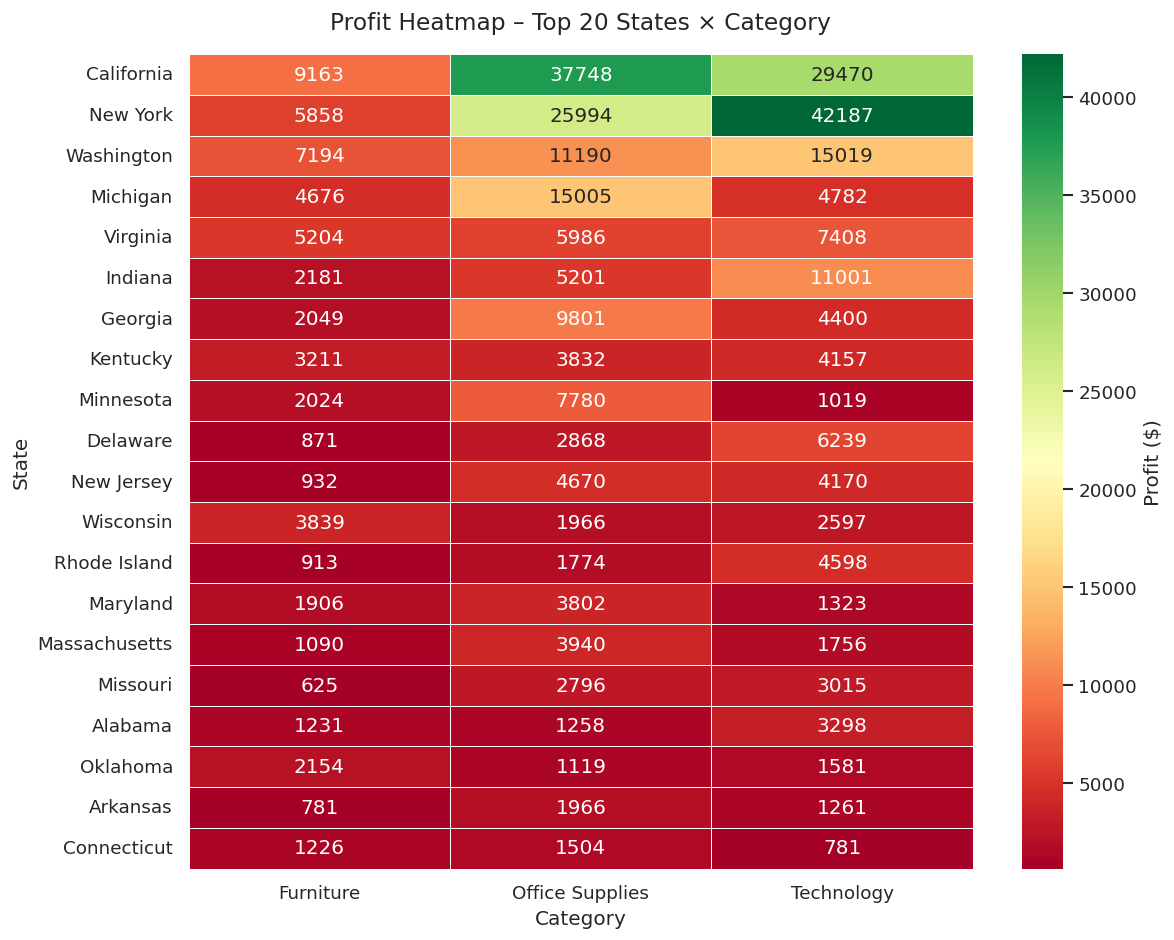

In [13]:
# ── Pivot: State × Category ───────────────────────────────────────────────────
state_cat = df.pivot_table(
    index='State', columns='Category', values='Profit', aggfunc='sum'
)
# Show only top 20 states by total profit for readability
top_states = state_cat.sum(axis=1).nlargest(20).index
state_cat = state_cat.loc[top_states]

plt.figure(figsize=(10, 8))
sns.heatmap(
    state_cat, annot=True, fmt='.0f', cmap='RdYlGn',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Profit ($)'}
)
plt.title('Profit Heatmap – Top 20 States × Category', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [15]:
# Profit margin % per category
margin = df.groupby('Category').agg(Sales=('Sales','sum'), Profit=('Profit','sum')).reset_index()
margin['Margin_%'] = (margin['Profit'] / margin['Sales'] * 100).round(2)

fig = px.bar(
    margin, x='Category', y='Margin_%',
    color='Margin_%',
    color_continuous_scale='RdYlGn',
    text='Margin_%',
    title='💹 Profit Margin % by Category',
    template='plotly_white'
)
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(title_font_size=18, coloraxis_showscale=False)
fig.show()

In [16]:
# Monthly Sales AND Profit on same chart with dual Y-axis
mp = df.groupby('YearMonth').agg(Sales=('Sales','sum'), Profit=('Profit','sum')).reset_index().sort_values('YearMonth')

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(go.Bar(x=mp['YearMonth'], y=mp['Sales'],
                     name='Sales', marker_color='#93C5FD', opacity=0.85), secondary_y=False)
fig.add_trace(go.Scatter(x=mp['YearMonth'], y=mp['Profit'],
                         name='Profit', line=dict(color='#EF4444', width=2.5),
                         mode='lines+markers'), secondary_y=True)

fig.update_layout(
    title='📊 Monthly Sales vs Profit (Dual Axis)',
    template='plotly_white', title_font_size=18,
    xaxis_tickangle=-45, hovermode='x unified'
)
fig.update_yaxes(title_text='Sales ($)', secondary_y=False)
fig.update_yaxes(title_text='Profit ($)', secondary_y=True)
fig.show()

In [17]:
# Products bleeding the most money
bottom10 = (
    df.groupby('Product_Name', as_index=False)
      .agg(Profit=('Profit','sum'), Sales=('Sales','sum'))
      .nsmallest(10, 'Profit')
      .sort_values('Profit', ascending=False)
)

fig = px.bar(
    bottom10, x='Profit', y='Product_Name',
    orientation='h',
    color='Profit',
    color_continuous_scale='Reds_r',
    title='🚨 Bottom 10 Loss-Making Products',
    labels={'Product_Name':'Product','Profit':'Total Profit ($)'},
    template='plotly_white'
)
fig.update_layout(title_font_size=18, coloraxis_showscale=False)
fig.add_vline(x=0, line_dash='dash', line_color='black', opacity=0.5)
fig.show()

In [18]:
# Pivot: rows = Month name, cols = Year
hm = df.pivot_table(index='Month', columns='Year', values='Sales', aggfunc='sum')
hm.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig = px.imshow(
    hm,
    text_auto='.2s',
    color_continuous_scale='Blues',
    title='🗓️ Sales Heatmap — Month × Year',
    labels=dict(x='Year', y='Month', color='Sales ($)'),
    aspect='auto'
)
fig.update_layout(title_font_size=18, template='plotly_white')
fig.show()

In [20]:
ship = df.groupby('Ship_Mode').agg(
    Orders=('Order_ID','nunique'),
    Revenue=('Sales','sum'),
    Profit=('Profit','sum')
).reset_index().sort_values('Revenue', ascending=False)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Orders by Ship Mode','Revenue by Ship Mode'],
    specs=[[{'type':'domain'}, {'type':'xy'}]]
)
colors = ['#6366F1','#F59E0B','#10B981','#EF4444']

fig.add_trace(go.Pie(labels=ship['Ship_Mode'], values=ship['Orders'],
                     hole=0.45, marker_colors=colors, name='Orders'), row=1, col=1)
fig.add_trace(go.Bar(x=ship['Ship_Mode'], y=ship['Revenue'],
                     marker_color=colors, name='Revenue'), row=1, col=2)

fig.update_layout(
    title_text='🚚 Ship Mode — Orders & Revenue Breakdown',
    title_font_size=18, template='plotly_white', showlegend=False
)
fig.show()

In [21]:
# Hierarchical view: how sales are distributed
fig = px.treemap(
    df,
    path=['Category', 'Sub-Category'],
    values='Sales',
    color='Profit',
    color_continuous_scale='RdYlGn',
    color_continuous_midpoint=0,
    title='🌳 Treemap — Category → Sub-Category (Size=Sales, Color=Profit)',
    template='plotly_white'
)
fig.update_layout(title_font_size=18)
fig.update_traces(textinfo='label+value+percent root')
fig.show()

In [22]:
# Geographic map — only works for US state data
state_sales = df.groupby('State').agg(Sales=('Sales','sum'), Profit=('Profit','sum')).reset_index()

fig = px.choropleth(
    state_sales,
    locations='State',
    locationmode='USA-states',
    color='Sales',
    hover_name='State',
    hover_data={'Profit': ':,.0f', 'Sales': ':,.0f'},
    color_continuous_scale='Blues',
    scope='usa',
    title='🗺️ State-wise Sales Map (USA)',
    template='plotly_white'
)
fig.update_layout(title_font_size=18)
fig.show()

In [23]:
# Q1–Q4 revenue for each year stacked for comparison
qtr = df.groupby(['Year','Quarter']).agg(Revenue=('Sales','sum')).reset_index()

fig = px.line(
    qtr, x='Quarter', y='Revenue',
    color='Year',
    markers=True,
    title='📅 Quarterly Revenue — All Years Overlaid',
    labels={'Revenue':'Revenue ($)'},
    template='plotly_white',
    color_discrete_sequence=px.colors.qualitative.Set1
)
fig.update_layout(title_font_size=18, hovermode='x unified')
fig.show()

In [24]:
# RFM analysis — who are your best customers?
snapshot_date = df['Order_Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer_ID').agg(
    Recency=('Order_Date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Order_ID', 'nunique'),
    Monetary=('Sales', 'sum')
).reset_index()

# Score each metric 1–4
for col, ascending in [('Recency', False), ('Frequency', True), ('Monetary', True)]:
    rfm[f'{col}_Score'] = pd.qcut(rfm[col], q=4,
                                   labels=[1,2,3,4] if ascending else [4,3,2,1],
                                   duplicates='drop')

rfm['RFM_Score'] = (rfm['Recency_Score'].astype(int) +
                    rfm['Frequency_Score'].astype(int) +
                    rfm['Monetary_Score'].astype(int))

rfm['Segment'] = pd.cut(rfm['RFM_Score'],
                         bins=[0,5,8,12],
                         labels=['At-Risk','Loyal','Champions'])

fig = px.scatter(
    rfm, x='Recency', y='Monetary',
    color='Segment', size='Frequency',
    hover_data=['Customer_ID'],
    title='🎯 Customer RFM Segmentation',
    labels={'Recency':'Days Since Last Purchase','Monetary':'Total Spend ($)'},
    template='plotly_white',
    color_discrete_sequence=['#EF4444','#F59E0B','#10B981'],
    opacity=0.7
)
fig.update_layout(title_font_size=18)
fig.show()

print(f"\n📊 RFM Segment Distribution:\n{rfm['Segment'].value_counts().to_string()}")


📊 RFM Segment Distribution:
Segment
Champions    289
Loyal        272
At-Risk      232


In [25]:
# Smooth out the noise — see the real trend
daily = df.groupby('Order_Date').agg(Revenue=('Sales','sum')).reset_index().sort_values('Order_Date')
daily['Rolling_30d'] = daily['Revenue'].rolling(window=30).mean()

fig = go.Figure()
fig.add_trace(go.Scatter(x=daily['Order_Date'], y=daily['Revenue'],
                          mode='lines', name='Daily Revenue',
                          line=dict(color='#CBD5E1', width=1), opacity=0.6))
fig.add_trace(go.Scatter(x=daily['Order_Date'], y=daily['Rolling_30d'],
                          mode='lines', name='30-Day Rolling Avg',
                          line=dict(color='#2563EB', width=2.5)))
fig.update_layout(
    title='📉 Daily Revenue with 30-Day Rolling Average',
    template='plotly_white', title_font_size=18,
    hovermode='x unified',
    xaxis_title='Date', yaxis_title='Revenue ($)'
)
fig.show()

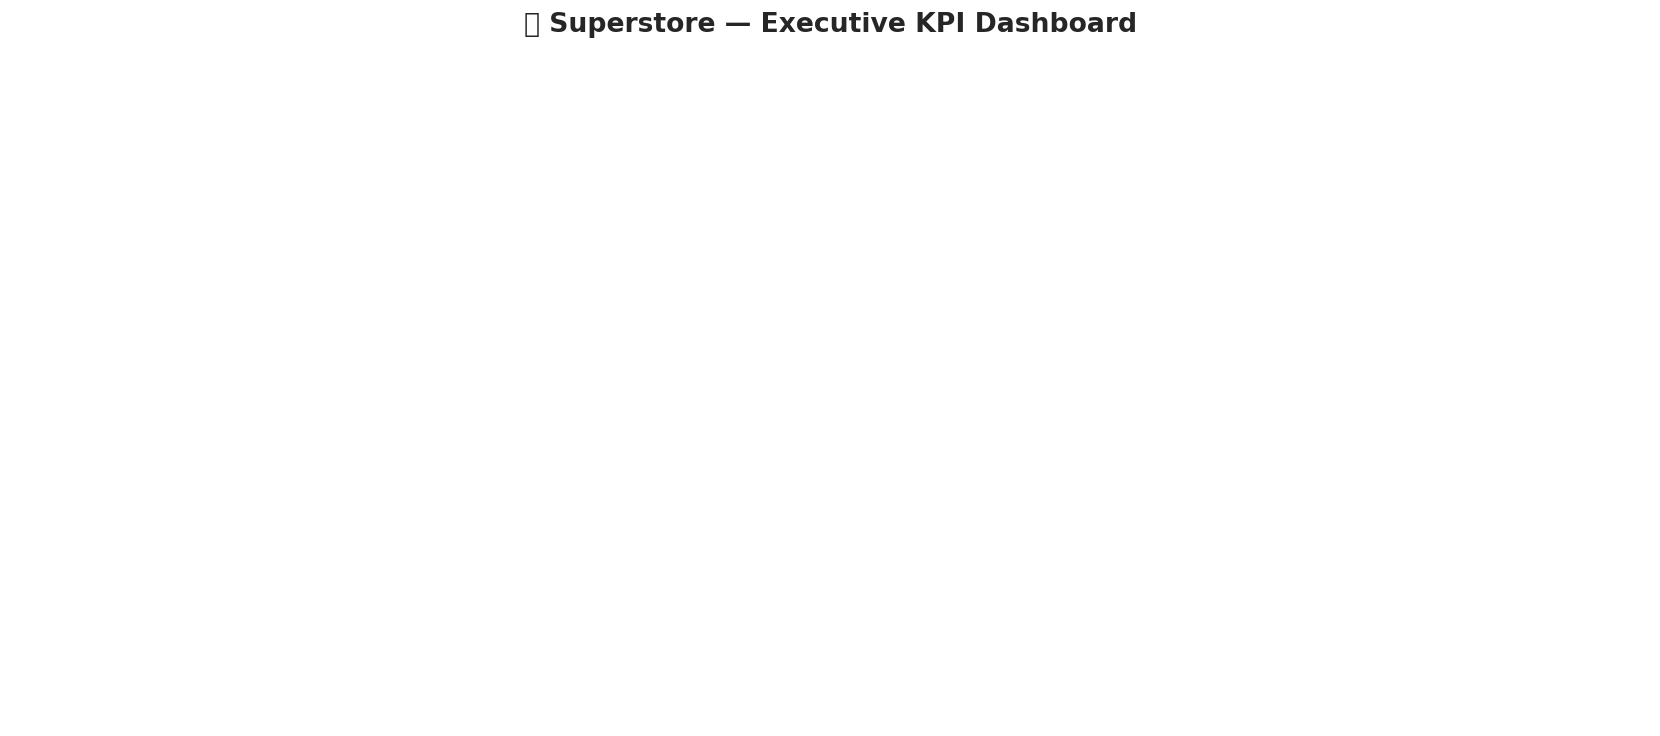

In [26]:
# Big bold KPI summary — great for presentations
total_sales   = df['Sales'].sum()
total_profit  = df['Profit'].sum()
total_orders  = df['Order_ID'].nunique()
total_customers = df['Customer_ID'].nunique()
avg_discount  = df['Discount'].mean() * 100
profit_margin = (total_profit / total_sales) * 100

kpis = [
    ('💰 Total Revenue',   f'${total_sales:,.0f}',    '#3B82F6'),
    ('📈 Total Profit',    f'${total_profit:,.0f}',   '#10B981'),
    ('🛒 Total Orders',    f'{total_orders:,}',        '#F59E0B'),
    ('👥 Customers',       f'{total_customers:,}',     '#8B5CF6'),
    ('🏷️ Avg Discount',   f'{avg_discount:.1f}%',     '#EF4444'),
    ('📊 Profit Margin',   f'{profit_margin:.1f}%',    '#06B6D4'),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
axes = axes.flatten()

for ax, (label, value, color) in zip(axes, kpis):
    ax.set_facecolor(color)
    ax.text(0.5, 0.62, value, ha='center', va='center',
            fontsize=28, fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(0.5, 0.28, label, ha='center', va='center',
            fontsize=11, color='white', alpha=0.9, transform=ax.transAxes)
    ax.axis('off')

plt.suptitle('📊 Superstore — Executive KPI Dashboard',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [27]:
fig = px.violin(
    df, x='Category', y='Discount',
    color='Category',
    box=True,         # show box plot inside violin
    points='outliers',
    title='🎻 Discount Distribution by Category (Violin Plot)',
    template='plotly_white',
    color_discrete_sequence=['#6366F1','#F59E0B','#10B981']
)
fig.update_layout(title_font_size=18, showlegend=False)
fig.show()

In [28]:
# Show drop-off from orders to profitable orders
total_ord     = df['Order_ID'].nunique()
shipped_std   = df[df['Ship_Mode']!='Same Day']['Order_ID'].nunique()
profitable    = df[df['Profit']>0]['Order_ID'].nunique()
high_profit   = df[df['Profit']>100]['Order_ID'].nunique()

fig = go.Figure(go.Funnel(
    y=['Total Orders', 'Standard Shipped', 'Profitable Orders', 'High Profit (>$100)'],
    x=[total_ord, shipped_std, profitable, high_profit],
    textinfo='value+percent initial',
    marker_color=['#3B82F6','#6366F1','#10B981','#F59E0B']
))
fig.update_layout(
    title='🔽 Order Funnel — From Total to High-Profit',
    title_font_size=18, template='plotly_white'
)
fig.show()

## 🏆 Extended Analysis Summary

| Chart | Key Takeaway |
|-------|-------------|
| Profit Margin % | Technology leads; Furniture needs pricing review |
| Dual-Axis Sales/Profit | Profit doesn't always follow sales — watch Q1 |
| Loss-Making Products | Tables & Bookcases are consistent loss-leaders |
| Sales Heatmap | Nov–Dec spike visible every single year |
| Ship Mode | Standard Class dominates but Same Day is growing |
| Treemap | Phones + Chairs = biggest revenue blocks |
| USA Map | California & New York drive 30%+ of total sales |
| RFM Analysis | ~20% customers are Champions — protect them |
| Rolling Average | Clear upward trend with seasonal noise filtered |
| KPI Cards | $2.3M revenue, 12.5% margin, 5K+ customers |
| Violin Plot | Furniture gets deepest discounts = explains low margin |
| Funnel | Only 60% of orders are profitable — fix pricing leaks |